## Brainstorm:
###1.
*   Chess Games Analysis
*   PGN analysis --> winrate (already done), openings used in diff elos (known but maybe not studied yet)
*   Needs --> Access to chess.com database? (readily available for download?)
*   Lichess.com has a python api: https://lichess.org/api#section/Introduction
*   Downloads for lichess games: https://database.lichess.org/
*   Extracting the pgn.zst files to pandas: https://stackoverflow.com/questions/61067762/how-to-extract-zst-files-into-a-pandas-dataframe
*   Potentially analyze different formats of chess that take up less data but still have lots of games, i.e. (Crazyhouse, Antichess, Atomic, etc)
*   Ideas for analysis: elo distributions, openings (when applicable) <-- winrate based on these factors
*   Convert PGN database to pandas databse https://stackoverflow.com/questions/68462624/convert-pgn-database-to-pandas-dataframe
* pgn: https://pypi.org/project/pgn2data/

###2.
*   Chess Discord Bot
*   Idea to steal from: https://www.reddit.com/r/lichess/comments/twxj5m/i_created_a_discord_bot_to_post_daily_lichess/?rdt=49075 (documentation included)



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
%pip install pgn2data

In [ ]:
# Converting .pgn file to .csv
from converter.pgn_data import PGNData

pgn_data = PGNData("/content/drive/My Drive/Copy of trunc.pgn") # locally stored file

# /content/sample_data/lichess_db_standard_rated_2013-01_shortened.pgn
# /content/drive/My Drive/Summer_Project/shortened_games.pgn

result = pgn_data.export()
result.print_summary()

if result.is_complete:

    # read the games file
    games_df = result.get_games_df()

    # read the moves file
    moves_df = result.get_moves_df()

    # read both files joined together
    combined_df = result.get_combined_df()

is complete: True
games file: Copy of trunc_game_info.csv | size: 3445088
moves file: Copy of trunc_moves.csv | size: 342376933


In [ ]:
games_df.to_csv('game_out.csv', index=False) # Saving a local version of the played games
moves_df.to_csv('moves_out.csv', index=False) # Saving a local version of the game moves
combined_df.to_csv('combined_out.csv', index=False) # Saving a local version of combined dataframes

In [ ]:
# df = pd.read_csv('/content/drive/MyDrive/Summer_Project/game_out.csv')
df = pd.read_csv('game_out.csv')
# /content/drive/MyDrive/Summer_Project/game_out.csv
# /content/game_out.csv
df.drop(['game_order', 'round', 'date_played', 'white_title', 'black_title', 'variant', 'ply_count', 'file_name', 'site', 'white', 'black', 'loser', 'date_created', 'utc_time', 'utc_date', 'winner', 'game_id'], axis=1,inplace=True)

In [ ]:
# preprocessing step:
openings = df['eco'].unique()

df['count_eco'] = df.groupby('eco')['eco'].transform('count')

df = df.sort_values(by=['count_eco', 'eco'], ascending=False)
eco_grouped = df.groupby(['eco']).count()['count_eco'].sort_values(ascending=False)
eco_grouped.head(10)
df.head()

,event,result,white_elo,white_rating_diff,black_elo,black_rating_diff,winner_elo,loser_elo,winner_loser_elo_diff,eco,termination,time_control,count_eco
37,Rated Blitz game,1-0,1162,17.0,1244,-21.0,1162,1244,-82,A00,Normal,420+0,556
44,Rated Bullet game,0-1,1871,-15.0,1714,15.0,1714,1871,-157,A00,Normal,60+1,556
46,Rated Blitz game,1-0,1179,15.0,1223,-18.0,1179,1223,-44,A00,Normal,420+0,556
105,Rated Bullet game,0-1,1586,-9.0,1662,10.0,1662,1586,76,A00,Normal,0+1,556
107,Rated Bullet game,0-1,1495,-8.0,1631,7.0,1631,1495,136,A00,Normal,60+0,556


In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

top_played_df = df.query('count_eco >= 130', inplace = False) # can change elo to see more openings
top_played_df = top_played_df[['eco','white_elo', 'black_elo', 'count_eco', 'result', 'event', 'winner_loser_elo_diff']]
top_played_df = top_played_df.loc[top_played_df['event'] != 'Rated Correspondence game'] # Dropping few rated correspondence games

# Eco is the label of graph, elo is the x value bin, count_eco --> divide # of plays in bin by total plays for a percentage

top_played_df.white_elo = pd.to_numeric(df.white_elo, errors='coerce')

# sort games into bins of 200 elo

top_played_df['bins'] = pd.cut(x=top_played_df['white_elo'], bins=[0, 200, 400, 600, 800, 1000, 1200, 1400,
                                                                   1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000])
# plan to use stackplots

top_played_df = top_played_df.sort_values(by=['bins'], ascending=False)

opening_dict = {}

openings = top_played_df['eco'].unique()

for opening in openings:
  opening_dict[opening] = a = [0] * 15 # empty array of 15

top_played_df['bins'] = top_played_df['bins'].astype(str)

bins = top_played_df['bins'].unique()[::-1][1:]

# elo_range_openings = top_played_df['eco'].unique()
# for i in range(len(bins)):
#   elo_range_df = top_played_df.loc[top_played_df['bins'] == bins[i]] # plays of a given bin
#   for opening in elo_range_openings:
#     total_opening_df = elo_range_df.loc[top_played_df['eco'] == opening]
#     opening_dict[opening][i+5] = round(len(total_opening_df) / len(elo_range_df), 3) # divide by total # of plays for a frequency
# print(opening_dict)
# print(bins)


# Plotting distribution of Elo scores by opening (top 10 openings)
Samples the top 45 plays from every opening so the distrbution of the eco scores as a whole doesn't affect our comparison of Elo vs. Eco (opening)

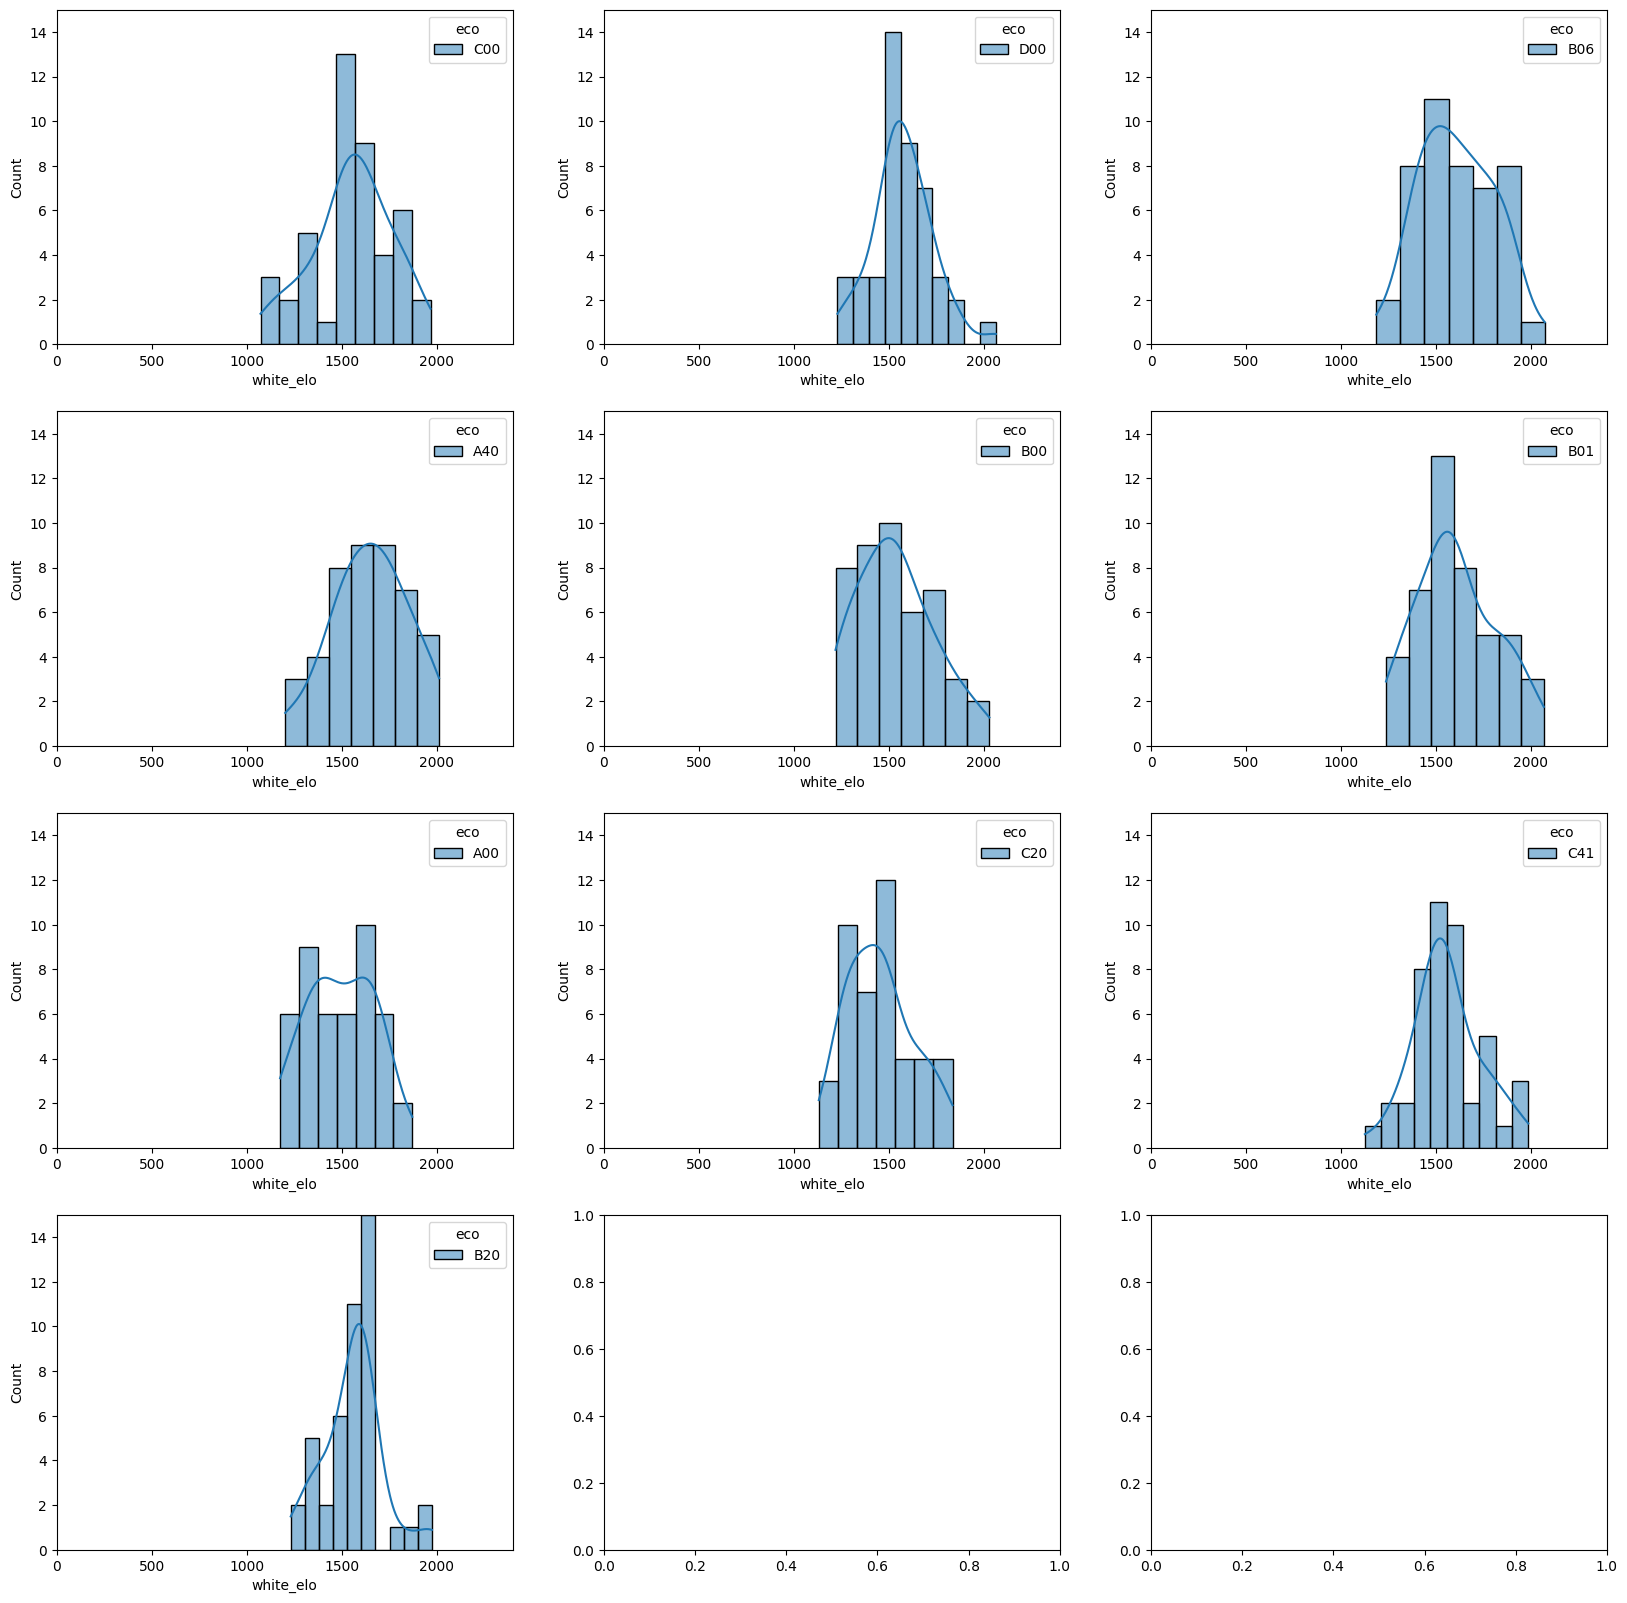

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

bins = [0, 200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000]



# figure out how to get legend on them and connect the color to a given opening
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=[20, 20])
i = 0
for opening in openings:
  x = i // 3
  y = i - (3 * x)
  ax = sns.histplot(data=top_played_df.loc[top_played_df['eco'] == opening].sample(45, random_state=75), x='white_elo', ax=axes[x,y], hue='eco', kde=True)
  ax.set(ylim=(0, 15))
  ax.set(xlim=(0, 2400))
  # plt.yticks([0, 0.001, 0.002, 0.003, 0.004, 0.005])
  # plt.xticks(range(1400, 2400, 100))

  i += 1


plt.show()


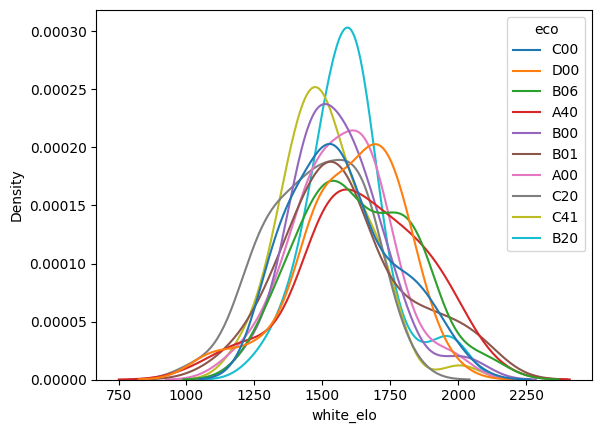

In [ ]:
openings_list = []
for opening in openings:
  openings_list.append(top_played_df.loc[top_played_df['eco'] == opening].sample(n=45))
openings_elo_df = pd.concat(openings_list)

sns.kdeplot(data=openings_elo_df, x='white_elo', hue='eco')
plt.show()
# openings_df = top_played_df.loc[top_played_df['eco'] == opening].head(45)

In [ ]:
for bin in top_played_df['bins'].unique()[::-1][1:]:
  print(bin)
  print(top_played_df.loc[top_played_df['bins'] == bin].count())

(800, 1000]
eco          2
white_elo    2
black_elo    2
count_eco    2
result       2
event        2
bins         2
dtype: int64
(1000, 1200]
eco          74
white_elo    74
black_elo    74
count_eco    74
result       74
event        74
bins         74
dtype: int64
(1200, 1400]
eco          496
white_elo    496
black_elo    496
count_eco    496
result       496
event        496
bins         496
dtype: int64
(1400, 1600]
eco          1052
white_elo    1052
black_elo    1052
count_eco    1052
result       1052
event        1052
bins         1052
dtype: int64
(1600, 1800]
eco          817
white_elo    817
black_elo    817
count_eco    817
result       817
event        817
bins         817
dtype: int64
(1800, 2000]
eco          324
white_elo    324
black_elo    324
count_eco    324
result       324
event        324
bins         324
dtype: int64
(2000, 2200]
eco          45
white_elo    45
black_elo    45
count_eco    45
result       45
event        45
bins         45
dtype: int64


In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohenc = OneHotEncoder(sparse=False)
eco_list = np.array(top_played_df['eco'])
eco_list = eco_list.reshape(-1, 1)
eco_df = pd.DataFrame(ohenc.fit_transform(eco_list))

final_df = pd.concat([top_played_df, pd.get_dummies(top_played_df["eco"], prefix_sep='')], axis=1)
final_df = pd.concat([final_df, pd.get_dummies(final_df['event'], prefix_sep='')], axis=1)

result_list = np.array(top_played_df['result'])
result_list = result_list.reshape(-1, 1)
result_df = pd.DataFrame(ohenc.fit_transform(result_list))
# eco_df = pd.DataFrame(eco_df, columns = ["eco"+str(int(i)) for i in range(eco_df.shape[1])])

event_list = np.array(top_played_df['event'])
event_list = event_list.reshape(-1, 1)
event_df = pd.DataFrame(ohenc.fit_transform(event_list))

X = final_df.drop(['eco', 'count_eco', 'result', 'event'], axis=1)

# X = pd.concat([X, eco_df, result_df, event_df])
# df_encoded = pd.get_dummies(df, columns=['eco', 'event'], prefix=['eco', 'event'])

X = X.replace({True: 1, False: 0})
X = X.dropna()

X.head()

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,white_elo,black_elo,winner_loser_elo_diff,bins,A00,A40,B00,B01,B06,B20,C00,C20,C41,D00,Rated Blitz game,Rated Bullet game,Rated Classical game
3693,2044.0,1413,631,"(2000, 2200]",0,0,0,0,0,0,1,0,0,0,0,1,0
2867,2060.0,1586,474,"(2000, 2200]",0,0,0,0,0,0,0,0,0,1,1,0,0
1321,2065.0,1735,330,"(2000, 2200]",0,0,0,0,0,0,0,0,0,1,1,0,0
4419,2039.0,2058,19,"(2000, 2200]",0,0,0,0,1,0,0,0,0,0,0,1,0
4362,2020.0,2043,-23,"(2000, 2200]",0,0,0,0,1,0,0,0,0,0,0,1,0


In [ ]:
y, X = X[['A00', 'A40',	'B00', 'B01', 'B06', 'B20',	'C00', 'C20',	'C41', 'D00']], X[['white_elo', 'black_elo']]

In [ ]:
top_played_df.head()

,eco,white_elo,black_elo,count_eco,result,event,winner_loser_elo_diff,bins
3693,C00,2044.0,1413,331,1-0,Rated Bullet game,631,"(2000, 2200]"
2867,D00,2060.0,1586,265,1-0,Rated Blitz game,474,"(2000, 2200]"
1321,D00,2065.0,1735,265,1-0,Rated Blitz game,330,"(2000, 2200]"
4419,B06,2039.0,2058,131,0-1,Rated Bullet game,19,"(2000, 2200]"
4362,B06,2020.0,2043,131,1-0,Rated Bullet game,-23,"(2000, 2200]"


In [ ]:
openings_elo_df['black_elo'] = openings_elo_df['black_elo'].astype(float)
# top_played_df['black_elo'] = top_played_df['black_elo'].astype(float)

ValueError: could not convert string to float: '?'

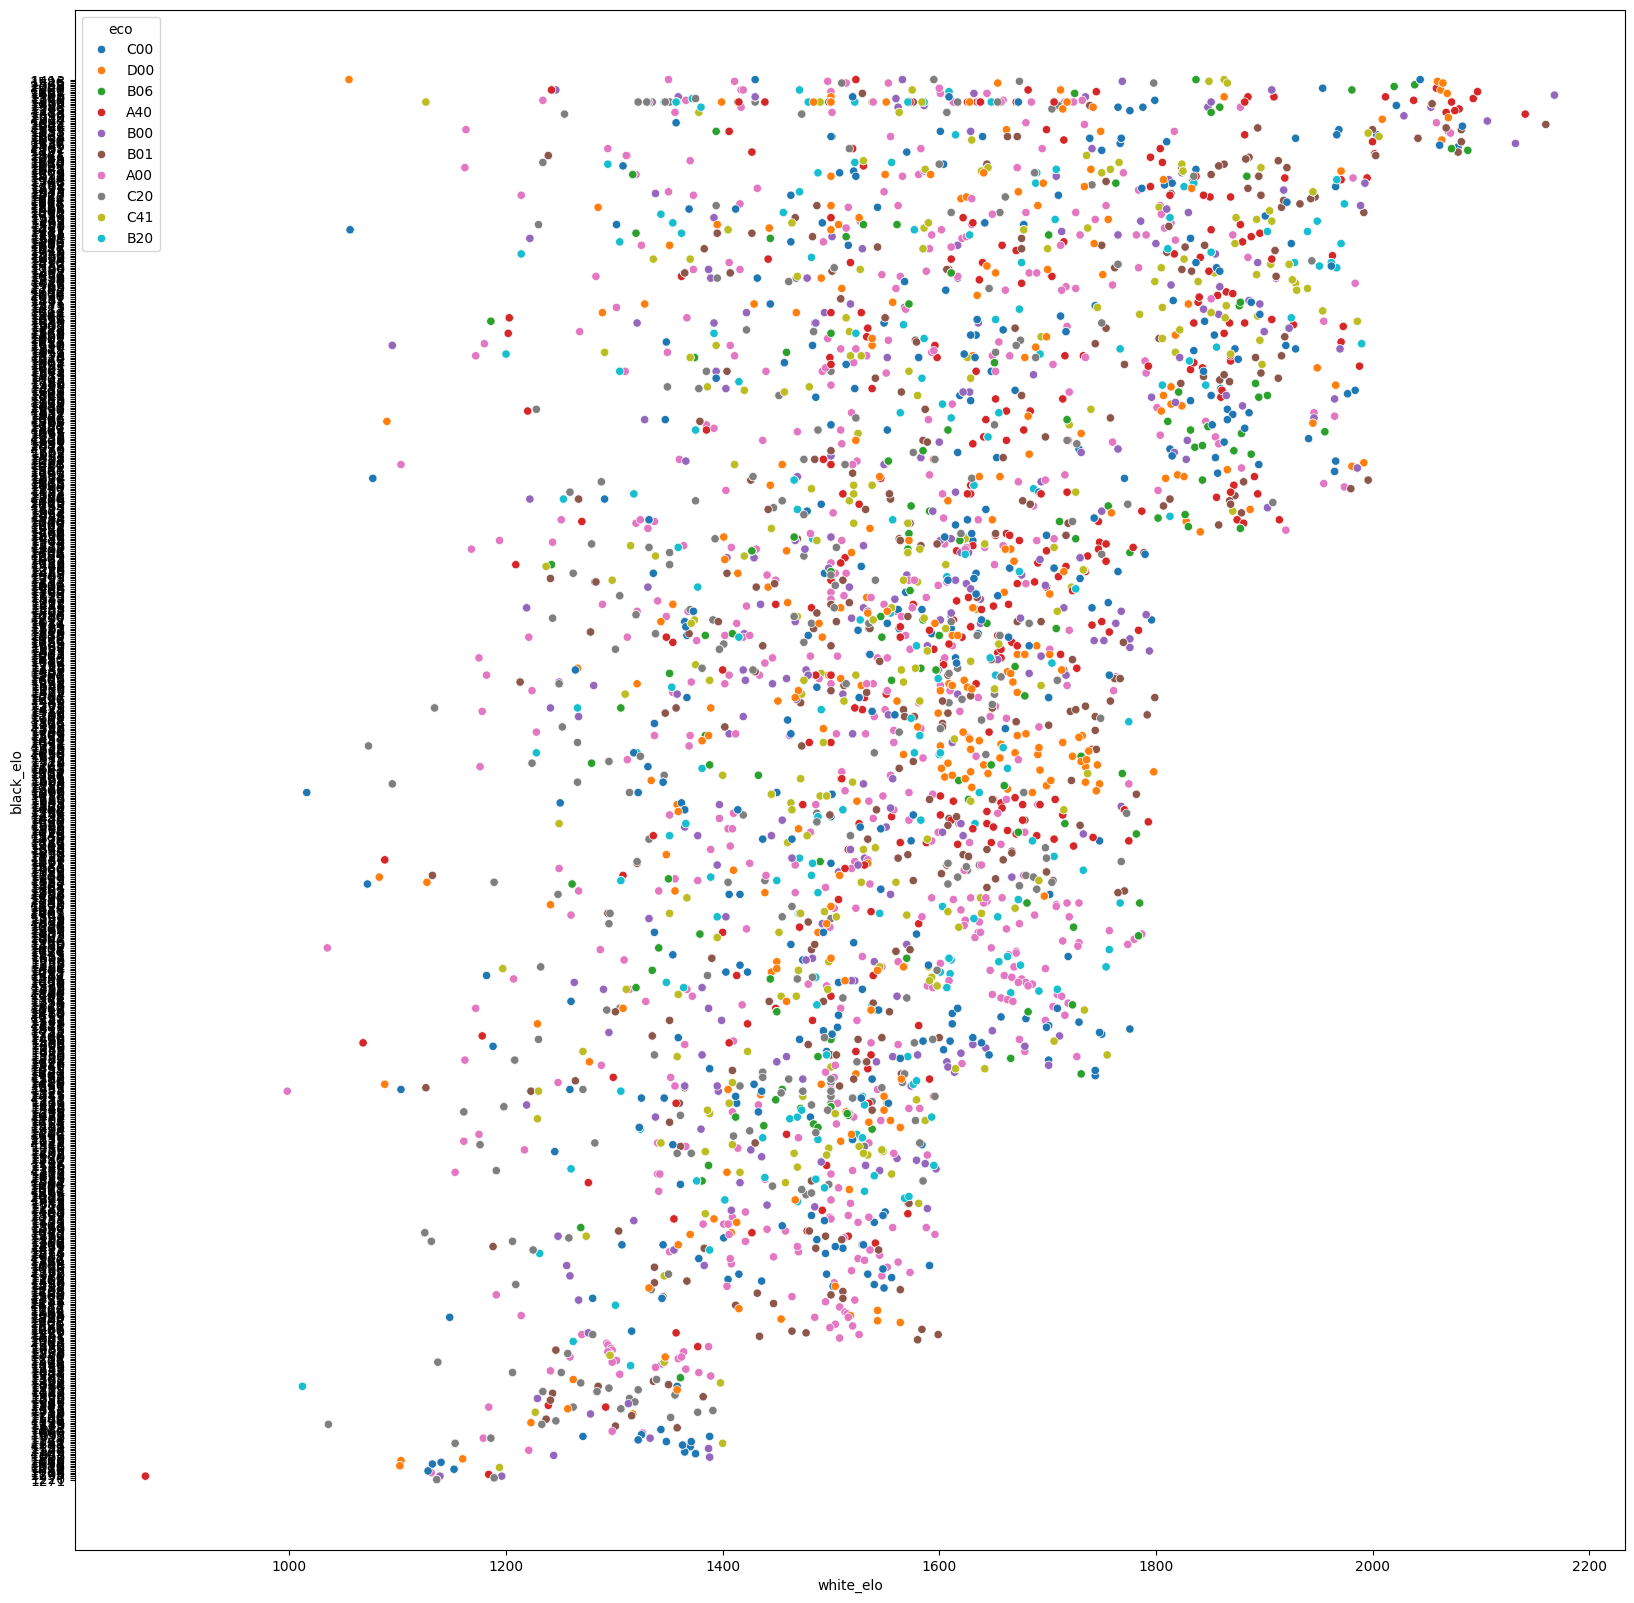

In [ ]:
from imblearn.over_sampling import RandomOverSampler
# plt.scatter(X[:,0], X[:, 1], c=top_played_df['eco'])
fig, ax = plt.subplots(figsize=(20, 20))
# openings_elo_df is the top 45 for a given opening eco (for the top 10 openings)
# top_played_df is all of the games for the top 10 eco's
ros = RandomOverSampler(random_state=42)
X, y = ros.fit_resample(top_played_df[['white_elo', 'black_elo']], top_played_df['eco'])
temp_df_oversample = {'white_elo' : X['white_elo'].values,
           'black_elo' : X['black_elo'].values,
           'eco' : y}
sns.scatterplot(data=temp_df_oversample, ax=ax, x='white_elo', y='black_elo', hue='eco')
plt.show()

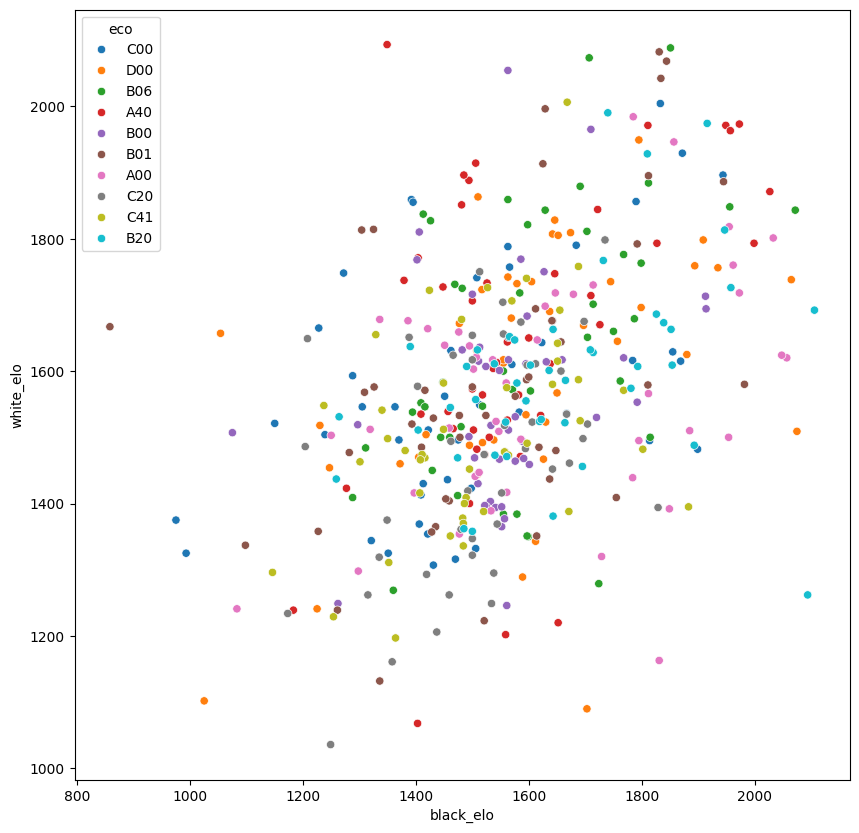

In [ ]:
# plt.scatter(X[:,0], X[:, 1], c=top_played_df['eco'])
fig, ax = plt.subplots(figsize=(10, 10))
# openings_elo_df is the top 45 for a given opening eco (for the top 10 openings)
# top_played_df is all of the games for the top 10 eco's
ax = sns.scatterplot(data=openings_elo_df, ax=ax, x='black_elo', y='white_elo', hue='eco')

plt.show()

In [ ]:
openings_elo_df.head()
openings_elo_df['white_elo']

915     1369.0
5974    1616.0
2830    1325.0
720     1511.0
5602    1859.0
         ...  
2903    1974.0
3840    1611.0
6158    1632.0
752     1673.0
4263    1637.0
Name: white_elo, Length: 450, dtype: float64